# <span style="color:green"> Numerical Simulation Laboratory (NSL)
#### Emma Franco
## <span style="color:blue">  Lecture 10</span>
### <span style= "color: black" > Es10.1

In questo esercizio viene parallelizzato l'algoritmo genetico dell'**Esercitazione 9**. In particolare, l'algoritmo viene parallelizzato tramite **MPI**, avviando più processi indipendenti, ciascuno identificato da un diverso `rank`.

Ogni processo esegue una copia completa dell'algoritmo genetico e fa evolvere una propria popolazione. Per rendere indipendenti le simulazioni, è stata modificata la funzione di generazione dei numeri casuali in modo da avere `rank` come secondo argomento: ``random_generator(rnd, rank)``.In questo modo, la funzione assegna a ciascun rank una diversa coppia di numeri primi letta dal file `Primes`, così da inizializzare in maniera differente il generatore casuale di ogni processo.

Ogni $N_{migr} = 20$ generazioni viene eseguita una migrazione. Il rank $0$ genera un ordine casuale dei processi tramite la funzione `permutate` e lo comunica a tutti gli altri rank utilizzando `MPI_Bcast`. Per esempio, con $4$ rank si può ottenere un vettore del tipo: $\{2, 0, 1, 3\}$.

Dopodiché, ogni rank invia il proprio miglior percorso al rank successivo nel vettore permutato e riceve il miglior percorso dal rank precedente. Gli estremi del vettore sono gestiti in modo da formare un anello: il rank in posizione $0$ riceve dall'ultimo rank e invia al rank in posizione $1$, mentre il rank nell'ultima posizione riceve dal rank precedente e invia al rank in posizione $0$.

La comunicazione viene effettuata mediante `MPI_Isend`, `MPI_Recv` e `MPI_Wait`. In particolare, `MPI_Isend` esegue un invio non bloccante: avvia l'operazione di invio senza attendere che questa sia completata. In questo modo, ogni processo può iniziare l'invio e successivamente eseguire la ricezione, evitando che tutti i rank rimangano bloccati in attesa reciproca. La funzione `MPI_Wait` viene poi utilizzata per attendere il completamento effettivo dell'invio prima di proseguire e riutilizzare il buffer associato.

L'individuo ricevuto sostituisce il peggior individuo della popolazione locale. Successivamente, ne viene ricalcolata la distanza e la popolazione viene riordinata in ordine di distanza crescente.

La variabile `migration` permette di eseguire il programma in due modalità:

- `migration = false`: algoritmi genetici indipendenti;
- `migration = true`: algoritmi genetici con migrazioni periodiche.

In questo modo è possibile confrontare l'efficacia dello scambio dei migliori individui con quella di più ricerche genetiche completamente indipendenti.

### <span style= "color: black" > Es10.2

In questo esercizio l'algoritmo genetico sviluppato in precedenza viene applicato al problema del commesso viaggiatore nel caso dei $110$ capoluoghi di provincia italiani. Le posizioni delle città sono fornite in termini di longitudine e latitudine e sono contenute nel file `cap_prov_ita.dat`.

Il problema di ottimizzazione del percorso viene studiato in due configurazioni differenti: nel primo caso i processi comunicano tra loro e permettono la migrazione periodica dei migliori individui; nel secondo caso, invece, i processi evolvono in modo completamente indipendente, senza alcuno scambio di individui.

Per sfruttare i vantaggi del calcolo parallelo, la simulazione è stata eseguita utilizzando $4$ rank, corrispondenti al numero di core logici disponibili sul computer utilizzato. Il codice supporta comunque l'esecuzione con un numero maggiore di rank.

#### <span style= "color: black" > Caso con migrazioni

Si riportano qui sotto due grafici:

1. Andamento di $L^{(1)}$ (definita nell'Esercitazione 9) **best** in funzione del numero di generazioni e per tutti i rank utilzzati.
2. Andamento di $\langle L^{(1)}\rangle$ calcolata sulla metà migliore di ogni ppolazione in funzione del numero di generazioni e per tutti i rank utilzzati.

Viene inoltre riportato il miglior valore di $L^{(1)}$ ed il valore del rank che lo trova.

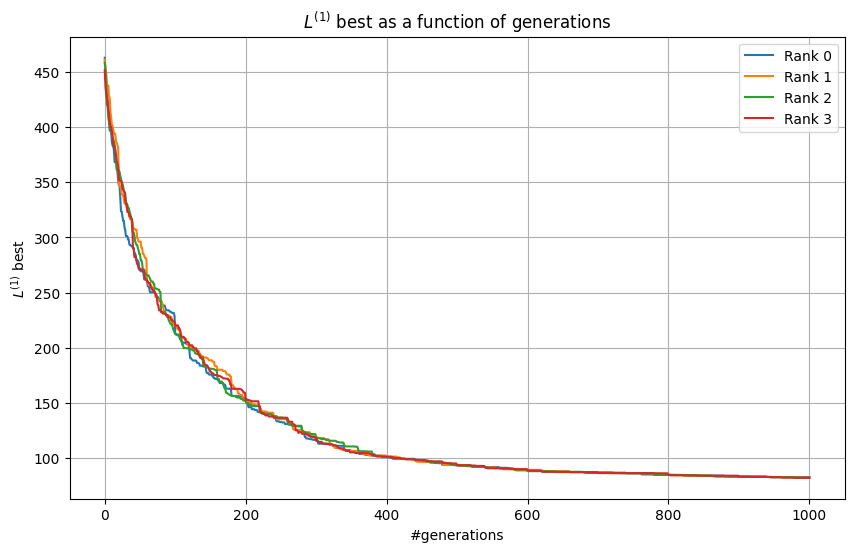

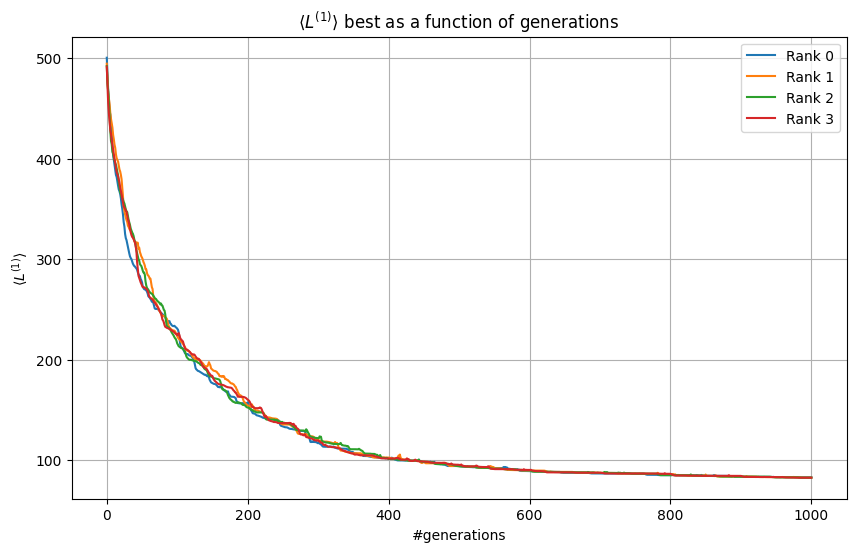

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot(filenames, title, y_name, n):
    plt.figure(figsize=(10, 6))

    # Each file contains the results produced independently by one MPI process
    for rank, filename in enumerate(filenames):
        # Column 1 stores the best path length of the current generation
        if n == 0:
            x, y = np.loadtxt(filename, usecols=(0, 1), unpack=True)
        # Column 2 stores the average path length over the best half of the population
        elif n == 1:
            x, y = np.loadtxt(filename, usecols=(0, 2), unpack=True)

        plt.plot(x, y, "-", linewidth=1.5, label=f"Rank {rank}")

    plt.xlabel("#generations")
    plt.title(title)
    plt.ylabel(y_name)
    plt.legend()
    plt.grid(True)
    plt.show()

filenames = ["Migration/outputL1_best_rank0.txt", "Migration/outputL1_best_rank1.txt", "Migration/outputL1_best_rank2.txt", "Migration/outputL1_best_rank3.txt"]

plot(filenames, r'$L^{(1)}$ best as a function of generations', r'$L^{(1)}$ best', 0)
plot(filenames, r'$\langle L^{(1)}\rangle$ best as a function of generations', r'$\langle L^{(1)}\rangle$', 1)

In [7]:
# Function to identify the MPI rank that obtains the shortest final path
def best_rank(filenames):
    best_values = []    # Empty list to store the final optimized path length obtained by each rank

    for rank, filename in enumerate(filenames):
        x, y = np.loadtxt(filename, usecols=(0, 1), unpack=True)
        best_values.append(y[-1])   # Keep the final value reached by the current rank

    best_rank = np.argmin(best_values)  # Return the position of the smallest final path length
    best_value = best_values[best_rank]

    return best_rank, best_value

In [8]:
filenames = ["Migration/outputL1_best_rank0.txt", "Migration/outputL1_best_rank1.txt", "Migration/outputL1_best_rank2.txt", "Migration/outputL1_best_rank3.txt"]
rank_best, L_best = best_rank(filenames)

print("Best rank =", rank_best)
print("Best final L1 =", L_best)

Best rank = 2
Best final L1 = 82.4748


#### <span style= "color: black" > Caso senza migrazioni

Come nella sezione precedente si riportano
1. Andamento di $L^{(1)}$ (definita nell'Esercitazione 9) **best** in funzione del numero di generazioni e per tutti i rank utilzzati.
2. Andamento di $\langle L^{(1)}\rangle$ calcolata sulla metà migliore di ogni ppolazione in funzione del numero di generazioni e per tutti i rank utilzzati.
3. Miglior valore di $L^{(1)}$ ed il valore del rank che lo trova.

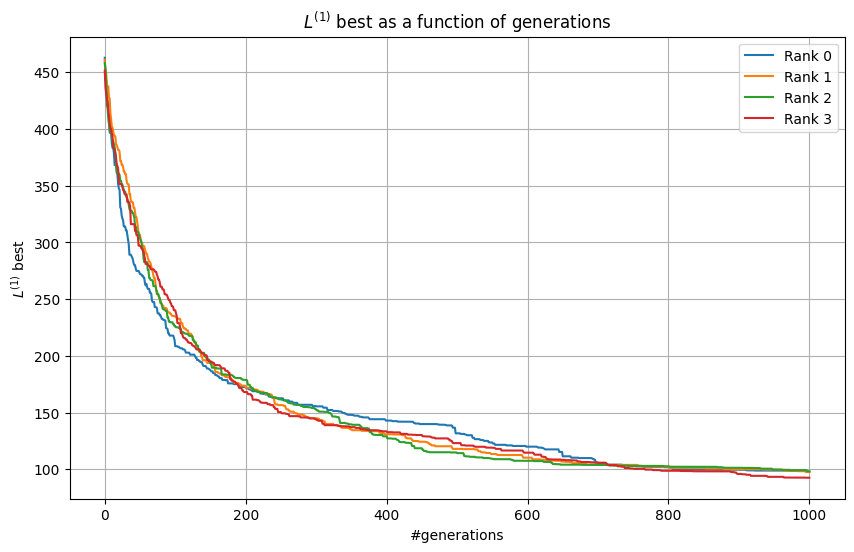

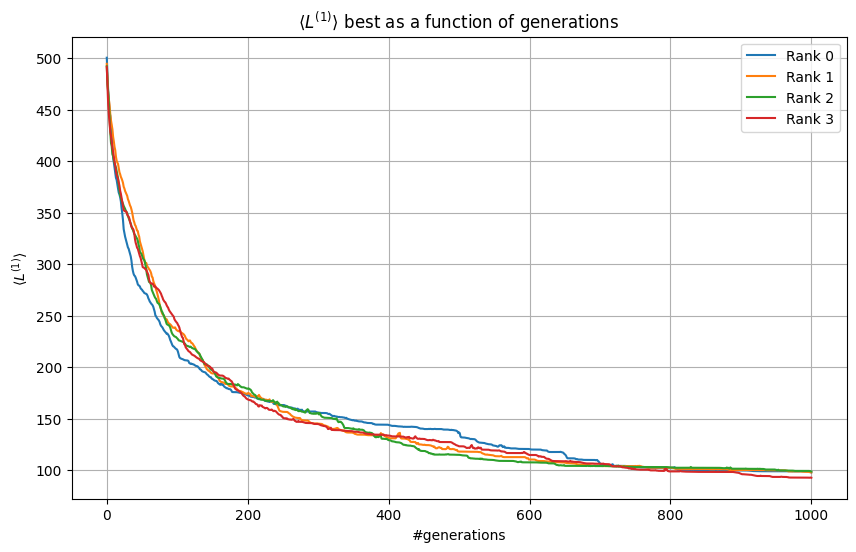

In [10]:
filenames = ["NoMigration/outputL1_best_rank0.txt", "NoMigration/outputL1_best_rank1.txt", "NoMigration/outputL1_best_rank2.txt", "NoMigration/outputL1_best_rank3.txt"]

plot(filenames, r'$L^{(1)}$ best as a function of generations', r'$L^{(1)}$ best', 0)
plot(filenames, r'$\langle L^{(1)}\rangle$ best as a function of generations', r'$\langle L^{(1)}\rangle$', 1)

In [11]:
filenames = ["NoMigration/outputL1_best_rank0.txt", "NoMigration/outputL1_best_rank1.txt", "NoMigration/outputL1_best_rank2.txt", "NoMigration/outputL1_best_rank3.txt"]
rank_best, L_best = best_rank(filenames)

print("Best rank =", rank_best)
print("Best final L1 =", L_best)

Best rank = 3
Best final L1 = 92.6273


Si verifica effettivamene che viene raggiunto un valore minore di $L^{(1)}$ nel caso in cui avviene la migrazione degli individui migliori, cioè nel caso in cui i processi coinvolti comunicano fra loro.